# IC / NC Hierarchical Classifier — Subject Z

Adaptation of **Salazar-Ramirez et al. (2019)** *(PLoS ONE)* for the Go/NoGo paradigm.

**Two-level architecture (paper):**
- **Level 1** — K-means clustering → IC vs NC (unsupervised, FPR-controlled ≤ 10 %)
- **Level 2** — SVM → which IC class (not needed here: single action)

**Key adaptations from paper:**

| Paper | This notebook |
|---|---|
| Motor imagery, 60 channels | Go/NoGo actual press, 16 channels |
| 5-class CSP per class | 2-class CSP (GO vs NoGo) |
| Bands: 8–12, 12–20, 20–30 Hz (ERD) | Bands: 0.5–4 Hz (MRCP), 4–8 Hz (theta) |
| IC epoch: 3 s imagined movement | IC epoch: −200 → +800 ms around stimulus |
| NC epoch: 0–2 s rest before cue | NC epoch: NoGo trial, same window |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mne.filter import filter_data

## Config

In [2]:
SUBJECT    = "Z"
DATE       = "20260618"
PREFIX     = SUBJECT
ROOT       = f"../data/subject{SUBJECT}"

FS         = 250.0
STIM_PRE   = 0.2        # s before stimulus onset  (baseline window)
STIM_POST  = 0.8        # s after  stimulus onset
N_PRE      = int(STIM_PRE  * FS)   # 50 samples
N_POST     = int(STIM_POST * FS)   # 200 samples
N_EPOCH    = N_PRE + N_POST         # 250 samples = 1 s

ALL_COLS   = [f"ch{i}" for i in range(16)]
N_CH       = 16

# CSP: N_CSP components from each end of the eigenspectrum
N_CSP      = 3       # → 2*N_CSP = 6 spatial projections

# Frequency bands (adapted for real movement / Go-NoGo)
BANDS      = [(0.5, 4.0), (4.0, 8.0)]
BAND_NAMES = ["delta 0.5–4 Hz (MRCP)", "theta 4–8 Hz"]

# K-means grid (same as paper)
K_VALUES   = [5, 10, 15, 20, 25, 30, 35, 40]
IC_THRS    = [0.60, 0.70, 0.80, 0.90]
MAX_FPR    = 0.10   # hard FPR ceiling from the paper
SEED       = 42

n_feat = 2 * N_CSP * len(BANDS) * 7
print(f"SUBJECT={SUBJECT}  DATE={DATE}")
print(f"Epoch: -{STIM_PRE*1000:.0f} ms → +{STIM_POST*1000:.0f} ms  ({N_EPOCH} samples)")
print(f"CSP projections: {2*N_CSP}  bands: {len(BANDS)}  features/epoch: {n_feat}")

SUBJECT=Z  DATE=20260618
Epoch: -200 ms → +800 ms  (250 samples)
CSP projections: 6  bands: 2  features/epoch: 84


## Load sessions

In [3]:
stamps = sorted(
    f.split("_")[-1][:-4]
    for f in os.listdir(ROOT)
    if f.startswith(f"{PREFIX}_eeg_{DATE}_") and f.endswith(".csv")
)
assert stamps, f"No EEG files found in {ROOT}"
print(f"Found {len(stamps)} session(s): {stamps}\n")

sessions = {}
for stamp in stamps:
    eeg_df = pd.read_csv(f"{ROOT}/{PREFIX}_eeg_{DATE}_{stamp}.csv")
    mrk_df = pd.read_csv(f"{ROOT}/{PREFIX}_markers_{DATE}_{stamp}.csv")
    raw_ts  = eeg_df["lsl_timestamp"].values
    raw_eeg = eeg_df[ALL_COLS].values.astype(np.float64)

    # ── Timestamp alignment (debounce-based) ──────────────────────────
    btn_ch    = eeg_df.iloc[:, -1].values.astype(bool)
    raw_edges = raw_ts[np.where(np.diff(btn_ch.astype(int)) > 0)[0] + 1]
    kept = []
    for t in raw_edges:
        if not kept or t - kept[-1] > 0.5:
            kept.append(t)
    deb_edges    = np.array(kept)
    press_mrk_ts = mrk_df.loc[mrk_df["marker_label"] == "button_press", "lsl_timestamp"].values
    n_pair       = min(len(deb_edges), len(press_mrk_ts))
    ts_offset    = float(np.median(deb_edges[:n_pair] - press_mrk_ts[:n_pair]))
    mrk_df["lsl_timestamp"] += ts_offset

    # ── Broadband 1–40 Hz + CAR (narrow bands applied per-feature later) ─
    broad = filter_data(raw_eeg.T, FS, 1.0, 40.0, verbose=False).T
    broad -= broad.mean(axis=1, keepdims=True)   # CAR
    broad = broad.astype(np.float32)

    sessions[stamp] = (raw_ts, broad, mrk_df)
    n_go   = (mrk_df.marker_code == 10).sum()
    n_nogo = (mrk_df.marker_code == 20).sum()
    print(f"  {stamp}: offset={ts_offset:.1f} s  {len(broad):,} smp  GO={n_go}  NoGo={n_nogo}")

Found 6 session(s): ['125821', '131405', '133154', '140110', '153514', '155418']

  125821: offset=1781276233.3 s  194,834 smp  GO=100  NoGo=100
  131405: offset=1781276233.3 s  193,373 smp  GO=100  NoGo=100
  133154: offset=1781276233.3 s  192,279 smp  GO=100  NoGo=100
  140110: offset=1781276233.3 s  188,991 smp  GO=100  NoGo=100
  153514: offset=1780742191.8 s  190,853 smp  GO=100  NoGo=100
  155418: offset=1780742191.8 s  191,897 smp  GO=100  NoGo=100


## Stimulus-locked epoch extraction

- **IC (y=1)** — Go trials: `go_onset` (marker code 10)
- **NC (y=0)** — NoGo trials: `nogo_onset` (marker code 20)
- Window: −200 ms → +800 ms around stimulus onset
- Baseline correction: subtract mean of the pre-stimulus window (−200–0 ms)

In [4]:
raw_all, y_all, s_all = [], [], []

for sid, stamp in enumerate(stamps):
    ts, broad, mrk = sessions[stamp]
    go_ts   = mrk.loc[mrk.marker_code == 10, "lsl_timestamp"].values
    nogo_ts = mrk.loc[mrk.marker_code == 20, "lsl_timestamp"].values

    n_ic = n_nc = 0
    for ts_arr, label in [(go_ts, 1), (nogo_ts, 0)]:
        for t0 in ts_arr:
            idx = np.searchsorted(ts, t0)
            i0, i1 = idx - N_PRE, idx + N_POST
            if i0 >= 0 and i1 <= len(broad):
                ep = broad[i0:i1].copy()          # (N_EPOCH, N_CH)
                ep -= ep[:N_PRE].mean(axis=0)     # baseline subtract
                raw_all.append(ep)
                y_all.append(label)
                s_all.append(sid)
                if label == 1: n_ic += 1
                else:          n_nc += 1

    print(f"  Session {sid} ({stamp}): IC/GO={n_ic}  NC/NoGo={n_nc}")

raw_all    = np.array(raw_all, dtype=np.float32)  # (N, N_EPOCH, N_CH)
y_all      = np.array(y_all,   dtype=np.int8)
s_all      = np.array(s_all,   dtype=np.int32)
n_sessions = len(stamps)
t_ax       = np.linspace(-STIM_PRE, STIM_POST, N_EPOCH) * 1000   # ms

print(f"\nTotal: {len(y_all)} epochs  IC={y_all.sum()}  NC={(y_all==0).sum()}  shape={raw_all.shape}")

  Session 0 (125821): IC/GO=99  NC/NoGo=100
  Session 1 (131405): IC/GO=100  NC/NoGo=100
  Session 2 (133154): IC/GO=100  NC/NoGo=100
  Session 3 (140110): IC/GO=100  NC/NoGo=100
  Session 4 (153514): IC/GO=99  NC/NoGo=100
  Session 5 (155418): IC/GO=100  NC/NoGo=100

Total: 1198 epochs  IC=598  NC=600  shape=(1198, 250, 16)


## Grand-average stimulus-locked ERP

IC (Go) vs NC (NoGo) — check for P300 (~300 ms) and N200 (~200 ms) components.

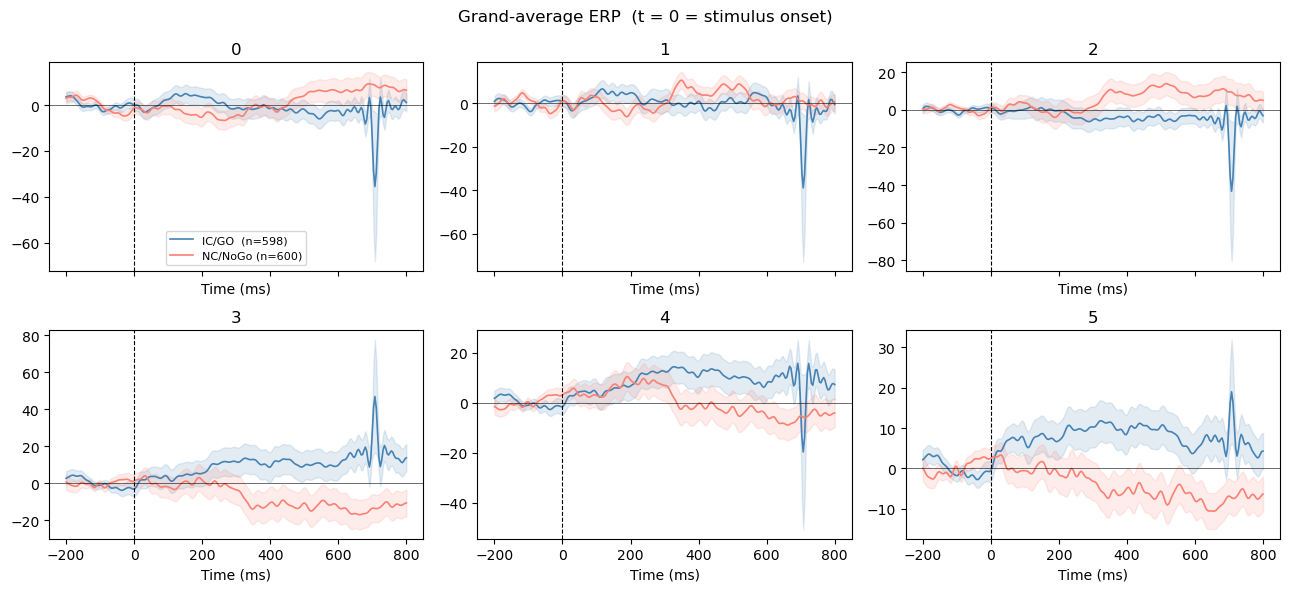

In [5]:
%matplotlib inline

SHOW_CHS  = range(16)#[1, 3, 5, 9, 11, 13]       # F3 C3 P3 F4 C4 P4
CH_NAMES  = range(16)#["F3","C3","P3","F4","C4","P4"]

ic_ep = raw_all[y_all == 1]
nc_ep = raw_all[y_all == 0]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, ch, name in zip(axes.flat, SHOW_CHS, CH_NAMES):
    m_ic = ic_ep[:, :, ch].mean(0);  s_ic = ic_ep[:, :, ch].std(0) / np.sqrt(len(ic_ep))
    m_nc = nc_ep[:, :, ch].mean(0);  s_nc = nc_ep[:, :, ch].std(0) / np.sqrt(len(nc_ep))
    ax.plot(t_ax, m_ic, color="steelblue", lw=1.2, label=f"IC/GO  (n={len(ic_ep)})")
    ax.plot(t_ax, m_nc, color="salmon",    lw=1.2, label=f"NC/NoGo (n={len(nc_ep)})")
    ax.fill_between(t_ax, m_ic-s_ic, m_ic+s_ic, alpha=0.15, color="steelblue")
    ax.fill_between(t_ax, m_nc-s_nc, m_nc+s_nc, alpha=0.15, color="salmon")
    ax.axvline(0,   color="k", lw=0.8, ls="--")
    ax.axhline(0,   color="k", lw=0.4)
    ax.set_title(name); ax.set_xlabel("Time (ms)")
    if ch == SHOW_CHS[0]: ax.legend(fontsize=8)

fig.suptitle("Grand-average ERP  (t = 0 = stimulus onset)")
plt.tight_layout(); plt.show()

## Feature extraction — no CSP (ERP-adapted)

CSP maximises variance ratio over the **whole epoch** — wrong for transient ERPs.
For P300 / N200, the discriminating signal is **time-localised** amplitude.

Replacement strategy:
1. Bandpass 0.5–20 Hz (captures ERP components, avoids muscle noise)
2. Divide epoch into 5 time windows aligned to ERP components
3. Mean amplitude per window × channel → feature vector

| Window | ms | Component |
|---|---|---|
| Baseline | −200 → 0 | Pre-stimulus |
| Early | 0 → 150 | Sensory / N1 |
| N200 | 150 → 300 | Response inhibition |
| P300 | 300 → 500 | Target detection |
| Late | 500 → 800 | Late positive |

With 16 channels × 5 windows = **80 features** (vs 84 with CSP — similar size, different structure).

In [ ]:
# ── Band filter (shared with CSP version) ────────────────────────────────

_BUTTER_CACHE = {}
def _bandpass(data_2d, lo, hi, fs=FS, order=4):
    """data_2d: (n_series, n_times) -> filtered"""
    key = (lo, hi)
    if key not in _BUTTER_CACHE:
        nyq  = fs / 2.0
        b, a = butter(order, [lo / nyq, hi / nyq], btype="band")
        _BUTTER_CACHE[key] = (b, a)
    b, a = _BUTTER_CACHE[key]
    return filtfilt(b, a, data_2d, axis=-1)


# ── ERP time windows ─────────────────────────────────────────────────────

ERP_BAND    = (0.5, 20.0)   # Hz — covers all ERP components
ERP_WINDOWS = [
    (-200,   0, "baseline"),
    (   0, 150, "early"),
    ( 150, 300, "N200"),
    ( 300, 500, "P300"),
    ( 500, 800, "late"),
]


def compute_features(epochs_raw, bands=None):
    """
    epochs_raw: (n_ep, n_t, n_ch)
    Returns:    (n_ep, n_windows * n_ch)  — mean amplitude per window per channel
    No CSP: all channels used directly.
    """
    n_ep, n_t, n_ch = epochs_raw.shape
    # Filter all channels at once
    lo, hi = ERP_BAND
    data_2d = np.ascontiguousarray(
        epochs_raw.transpose(0, 2, 1)
    ).reshape(n_ep * n_ch, n_t).astype(np.float64)
    filt_2d = _bandpass(data_2d, lo, hi)                  # (n_ep*n_ch, n_t)
    filt    = filt_2d.reshape(n_ep, n_ch, n_t).transpose(0, 2, 1)  # (n_ep, n_t, n_ch)

    all_feats = []
    for (w_ms0, w_ms1, _) in ERP_WINDOWS:
        mask = (t_ax >= w_ms0) & (t_ax < w_ms1)
        all_feats.append(filt[:, mask, :].mean(axis=1))   # (n_ep, n_ch)

    return np.concatenate(all_feats, axis=1).astype(np.float32)   # (n_ep, n_win*n_ch)


n_feat_erp = len(ERP_WINDOWS) * N_CH
print(f"Feature vector: {len(ERP_WINDOWS)} windows x {N_CH} channels = {n_feat_erp} features")
print(f"Windows (ms): {[(w[0],w[1]) for w in ERP_WINDOWS]}")

## LOSO hierarchical K-means classification

Same grid search as paper (K ∈ {5,10,…,40}, IC-threshold ∈ {60%,70%,80%,90%}).
No CSP — features are windowed ERP amplitudes per channel.

For each test session:
1. Extract + standardise ERP features
2. Grid-search K and IC-threshold on training set (FPR ≤ 10 %)
3. Apply best K-means to held-out session → accuracy + FPR

In [ ]:
def _predict(km, cluster_is_ic, X):
    return cluster_is_ic[km.predict(X)].astype(int)

def _metrics(y_pred, y_true):
    acc = (y_pred == y_true).mean()
    nc  = y_true == 0;  ic = y_true == 1
    fpr = y_pred[nc].mean() if nc.sum() else 0.0
    tpr = y_pred[ic].mean() if ic.sum() else 0.0
    return float(acc), float(fpr), float(tpr)

results = []

for test_sid in range(n_sessions):
    tr = s_all != test_sid;  te = s_all == test_sid
    ep_tr, y_tr = raw_all[tr], y_all[tr]
    ep_te, y_te = raw_all[te], y_all[te]

    # 1. Extract + standardise ERP features (no CSP)
    X_tr = compute_features(ep_tr)
    X_te = compute_features(ep_te)
    sc   = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    # 2. Grid search (K, IC-threshold) on training set
    best = {"acc": -1, "fpr": 1.0, "K": None, "thr": None, "km": None, "ci": None}
    grid = []
    for K in K_VALUES:
        for ic_thr in IC_THRS:
            km = KMeans(n_clusters=K, random_state=SEED, n_init=10, max_iter=300)
            km.fit(X_tr)
            ci = np.array([
                y_tr[km.labels_ == k].mean() >= ic_thr
                if (km.labels_ == k).sum() > 0 else False
                for k in range(K)
            ])
            y_pred_tr = _predict(km, ci, X_tr)
            acc_tr, fpr_tr, _ = _metrics(y_pred_tr, y_tr)
            grid.append({"K": K, "thr": ic_thr, "acc": acc_tr, "fpr": fpr_tr})
            if fpr_tr <= MAX_FPR and acc_tr > best["acc"]:
                best.update(acc=acc_tr, fpr=fpr_tr, K=K, thr=ic_thr, km=km, ci=ci)

    note = ""
    if best["K"] is None:
        row  = min(grid, key=lambda r: r["fpr"])
        km   = KMeans(n_clusters=row["K"], random_state=SEED, n_init=10).fit(X_tr)
        ci   = np.array([
            y_tr[km.labels_ == k].mean() >= row["thr"]
            if (km.labels_ == k).sum() > 0 else False
            for k in range(row["K"])
        ])
        best.update(km=km, ci=ci, K=row["K"], thr=row["thr"])
        note = "  ⚠ FPR>10%"

    # 3. Test
    y_pred_te = _predict(best["km"], best["ci"], X_te)
    acc_te, fpr_te, tpr_te = _metrics(y_pred_te, y_te)

    results.append({
        "session": test_sid, "stamp": stamps[test_sid],
        "K": best["K"], "thr": best["thr"],
        "acc_tr": best["acc"], "fpr_tr": best["fpr"],
        "acc_te": acc_te, "fpr_te": fpr_te, "tpr_te": tpr_te,
        "grid": grid,
        "km": best["km"], "ci": best["ci"],
        "scaler": sc,
    })
    print(f"  Fold {test_sid} ({stamps[test_sid]})  "
          f"K={best['K']} thr={best['thr']:.0%}  "
          f"tr acc={best['acc']:.3f} fpr={best['fpr']:.3f}  │  "
          f"te acc={acc_te:.3f} fpr={fpr_te:.3f} tpr={tpr_te:.3f}{note}")

mean_acc = np.mean([r["acc_te"] for r in results])
mean_fpr = np.mean([r["fpr_te"] for r in results])
mean_tpr = np.mean([r["tpr_te"] for r in results])
print(f"\nLOSO  acc={mean_acc:.3f}  FPR={mean_fpr:.3f}  TPR={mean_tpr:.3f}")

## Results

Session      Acc  FPR      TPR  K Thr
 125821 0.502513 0.02 0.020202 40 60%
 131405 0.495000 0.05 0.040000 35 60%
 133154 0.505000 0.05 0.060000 35 60%
 140110 0.495000 0.09 0.080000 40 60%
 153514 0.467337 0.29 0.222222 30 60%
 155418 0.510000 0.05 0.070000 35 60%

Mean  acc=0.496 ±0.015   FPR=0.092 ±0.100   TPR=0.082 ±0.072


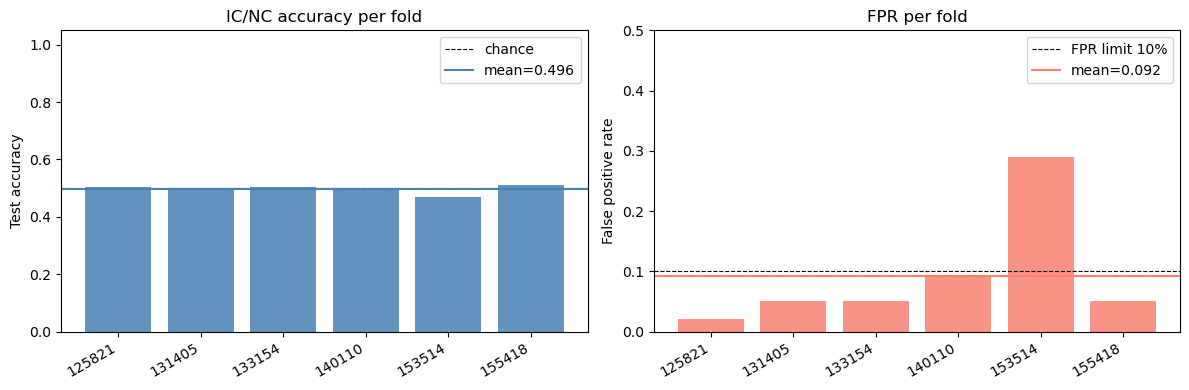

In [11]:
%matplotlib inline

df_res = pd.DataFrame([{
    "Session": r["stamp"], "Acc": r["acc_te"], "FPR": r["fpr_te"],
    "TPR": r["tpr_te"], "K": r["K"], "Thr": f'{r["thr"]:.0%}'
} for r in results])
print(df_res.to_string(index=False))
print(f"\nMean  acc={df_res.Acc.mean():.3f} ±{df_res.Acc.std():.3f}   "
      f"FPR={df_res.FPR.mean():.3f} ±{df_res.FPR.std():.3f}   "
      f"TPR={df_res.TPR.mean():.3f} ±{df_res.TPR.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(df_res))

ax = axes[0]
ax.bar(x, df_res.Acc, color="steelblue", alpha=0.85)
ax.axhline(0.5,              color="k",         ls="--", lw=0.8, label="chance")
ax.axhline(df_res.Acc.mean(), color="steelblue", ls="-",  lw=1.5,
           label=f"mean={df_res.Acc.mean():.3f}")
ax.set_xticks(x); ax.set_xticklabels(df_res.Session, rotation=30, ha="right")
ax.set_ylabel("Test accuracy"); ax.set_title("IC/NC accuracy per fold")
ax.legend(); ax.set_ylim(0, 1.05)

ax = axes[1]
ax.bar(x, df_res.FPR, color="salmon", alpha=0.85)
ax.axhline(MAX_FPR,           color="k",      ls="--", lw=0.8, label=f"FPR limit {MAX_FPR:.0%}")
ax.axhline(df_res.FPR.mean(), color="salmon", ls="-",  lw=1.5,
           label=f"mean={df_res.FPR.mean():.3f}")
ax.set_xticks(x); ax.set_xticklabels(df_res.Session, rotation=30, ha="right")
ax.set_ylabel("False positive rate"); ax.set_title("FPR per fold")
ax.legend(); ax.set_ylim(0, max(0.5, df_res.FPR.max() + 0.1))

plt.tight_layout(); plt.show()

## Grid-search heatmap — fold 0

Training accuracy and FPR across all (K, IC-threshold) combinations.
**Blue border** = FPR ≤ 10 % (valid region from which the best config is chosen).

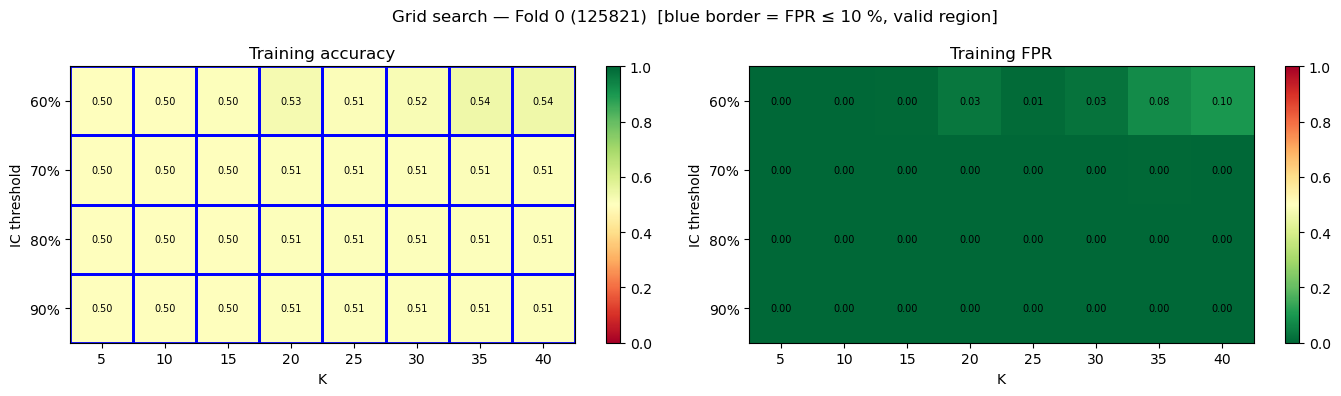

In [12]:
%matplotlib inline

FOLD_VIZ = 0
df_g = pd.DataFrame(results[FOLD_VIZ]["grid"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title, cmap in [
    (axes[0], "acc", "Training accuracy", "RdYlGn"),
    (axes[1], "fpr", "Training FPR",      "RdYlGn_r"),
]:
    piv = df_g.pivot(index="thr", columns="K", values=col)
    im  = ax.imshow(piv.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(K_VALUES))); ax.set_xticklabels(K_VALUES)
    ax.set_yticks(range(len(IC_THRS)));  ax.set_yticklabels([f"{t:.0%}" for t in IC_THRS])
    ax.set_xlabel("K"); ax.set_ylabel("IC threshold"); ax.set_title(title)
    for i in range(len(IC_THRS)):
        for j in range(len(K_VALUES)):
            ax.text(j, i, f"{piv.values[i,j]:.2f}", ha="center", va="center",
                    color="black", fontsize=7)

fpr_piv = df_g.pivot(index="thr", columns="K", values="fpr")
for i in range(len(IC_THRS)):
    for j in range(len(K_VALUES)):
        if fpr_piv.values[i, j] <= MAX_FPR:
            axes[0].add_patch(plt.Rectangle(
                (j-0.5, i-0.5), 1, 1, fill=False, edgecolor="blue", lw=2))

plt.suptitle(
    f"Grid search — Fold {FOLD_VIZ} ({stamps[FOLD_VIZ]})  "
    "[blue border = FPR ≤ 10 %, valid region]"
)
plt.tight_layout(); plt.show()

## PCA of feature space (fold 0)

2-D projection of all epochs coloured by true label, overlaid with K-means cluster centres — shows whether CSP features separate IC from NC.

In [ ]:
%matplotlib inline

FOLD_VIZ = 0
test_sid = FOLD_VIZ
tr = s_all != test_sid; te = s_all == test_sid
ep_tr, y_tr = raw_all[tr], y_all[tr]
ep_te, y_te = raw_all[te], y_all[te]

sc_viz   = results[FOLD_VIZ]["scaler"]
best_km  = results[FOLD_VIZ]["km"]
best_ci  = results[FOLD_VIZ]["ci"]

X_tr_std  = sc_viz.transform(compute_features(ep_tr))
X_te_std  = sc_viz.transform(compute_features(ep_te))
X_all_std = np.vstack([X_tr_std, X_te_std])
y_viz     = np.concatenate([y_tr, y_te])
split_mask = np.concatenate([np.zeros(len(y_tr)), np.ones(len(y_te))]).astype(bool)

pca = PCA(n_components=2, random_state=SEED)
Z   = pca.fit_transform(X_all_std)
centres = pca.transform(best_km.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mask, title in [
    (axes[0], ~split_mask, "Training set"),
    (axes[1],  split_mask, f"Test  ({stamps[FOLD_VIZ]})"),
]:
    z  = Z[mask]; yl = y_viz[mask]
    ax.scatter(z[yl==1,0], z[yl==1,1], c="steelblue", alpha=0.5, s=15, label="IC/GO")
    ax.scatter(z[yl==0,0], z[yl==0,1], c="salmon",    alpha=0.5, s=15, label="NC/NoGo")
    if title.startswith("Train"):
        ic_c = centres[best_ci];  nc_c = centres[~best_ci]
        if len(ic_c): ax.scatter(ic_c[:,0], ic_c[:,1], marker="*", s=120, c="navy",      label="IC centres")
        if len(nc_c): ax.scatter(nc_c[:,0], nc_c[:,1], marker="*", s=120, c="firebrick", label="NC centres")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle(f"PCA of ERP window features — Fold {FOLD_VIZ} ({stamps[FOLD_VIZ]})")
plt.tight_layout(); plt.show()